# Regime Strategy — Performance Analysis

Goal: *understand* how the regime overlay behaves and **why it lags buy & hold**, before tuning anything.

We use cached data (no refresh), run the leak-free walk-forward once, then inspect:
1. Equity curves (strategy vs buy & hold)
2. How the signal drives daily exposure (weights) in a representative period
3. A decomposition of the return gap — where does the underperformance come from?


In [15]:
# Setup: make the `regime` package importable from notebooks/ and import deps
import sys, time, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The project root is the parent of notebooks/. Add it to sys.path so we can
# `import regime.*` exactly like the CLI does (it runs with PYTHONPATH=.).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from regime import config, data, features, pipeline, backtest

# Reload in case the source changed since the kernel first imported it (avoids
# stale-module surprises like a missing dict key after an edit).
for _m in (config, data, features, pipeline, backtest):
    importlib.reload(_m)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("project root:", PROJECT_ROOT)
print("JUMP_PENALTY (config):", config.JUMP_PENALTY)
print("backtest.run returns keys incl. 'daily'? ->",
      "daily" in backtest.run.__doc__)


project root: /Users/wbelmont/Desktop/regime-monitor
JUMP_PENALTY (config): 50.0
backtest.run returns keys incl. 'daily'? -> True


## 1. Load cached data (no refresh)

Uses the parquet cache in `data/cache/` — instant, no network. This is the same
`feat` table the CLI builds.


In [16]:
# Load from the on-disk cache (refresh=False => no network call)
raw = data.load_raw(refresh=False)
feat = features.build_features(raw)
print(f"feat: {len(feat):,} rows, {feat.index.min().date()} -> {feat.index.max().date()}")
feat[["mkt_ret", "vix", "ma_ratio", "mom_126"]].tail(3)


feat: 6,646 rows, 2000-01-03 -> 2026-06-05


,mkt_ret,vix,ma_ratio,mom_126
2026-06-03,-0.0074,16.0600,1.0397,0.1088
2026-06-04,0.0041,15.4000,1.0418,0.1105
2026-06-05,-0.0264,21.5100,1.0434,0.0780


## 2. Run the walk-forward ONCE, with progress + disk cache

**Why the notebook hung before:** the full walk-forward refits the model monthly
across ~25 years (≈245 windows × ~3s = ~13 min) and the cell gives no visible
output, so it *looks* frozen.

Fixes here:
- **Live progress** prints every few windows, so you can see it moving.
- **Disk cache**: the signals are saved to `data/cache/`. Re-running this cell is
  then instant, and every analysis cell below reloads from the cache.
- **Fast presets** (`refit_every=63`, `n_init=5`) cut runtime to ~1–2 min while
  preserving the behavior. Set `FAST = False` for the full-rigor run later.


In [18]:
# Fast preset keeps the first run to ~1-2 min. Flip to False for full rigor (~13 min).
FAST = True
WF_KW = dict(refit_every=63, n_init=5, max_iter=30) if FAST else dict()

tag = f"jp{config.JUMP_PENALTY:g}_{'fast' if FAST else 'full'}"
cache_path = config.CACHE_DIR / f"signals_{tag}.parquet"

if cache_path.exists():
    signals = pd.read_parquet(cache_path)
    print(f"Loaded cached signals from {cache_path.name} ({len(signals):,} rows)")
else:
    t0 = time.time()
    last = {"t": t0}

    def on_step(done, total):
        # Print at the start, every 20 windows, and at the end — light but visible.
        if done == 1 or done % 20 == 0 or done == total:
            elapsed = time.time() - t0
            rate = elapsed / done
            eta = rate * (total - done)
            print(f"  window {done:>3}/{total}  |  {elapsed:5.0f}s elapsed  |  ~{eta:4.0f}s left")

    print(f"Running walk-forward ({tag}) — watch the progress below:")
    signals = pipeline.walk_forward(feat, progress=on_step, **WF_KW)
    signals.to_parquet(cache_path)
    print(f"Done in {time.time() - t0:.0f}s. Cached -> {cache_path.name}")

print(f"\nsignals: {len(signals):,} rows, "
      f"{signals.index.min().date()} -> {signals.index.max().date()}")
signals.head(3)


Running walk-forward (jp50_fast) — watch the progress below:


KeyboardInterrupt: 

## 3. Equity curves & headline metrics

`backtest.run` applies the continuous daily weights and the 10%/yr financing on
the leverage sleeve. We plot growth-of-$1 (log scale) and the drawdown paths.


,annual_return,annual_vol,sharpe,max_drawdown,total_return
strategy,0.0903,0.1878,0.4810,-0.3809,4.8223
buy_hold,0.0896,0.1939,0.4621,-0.5678,4.7441


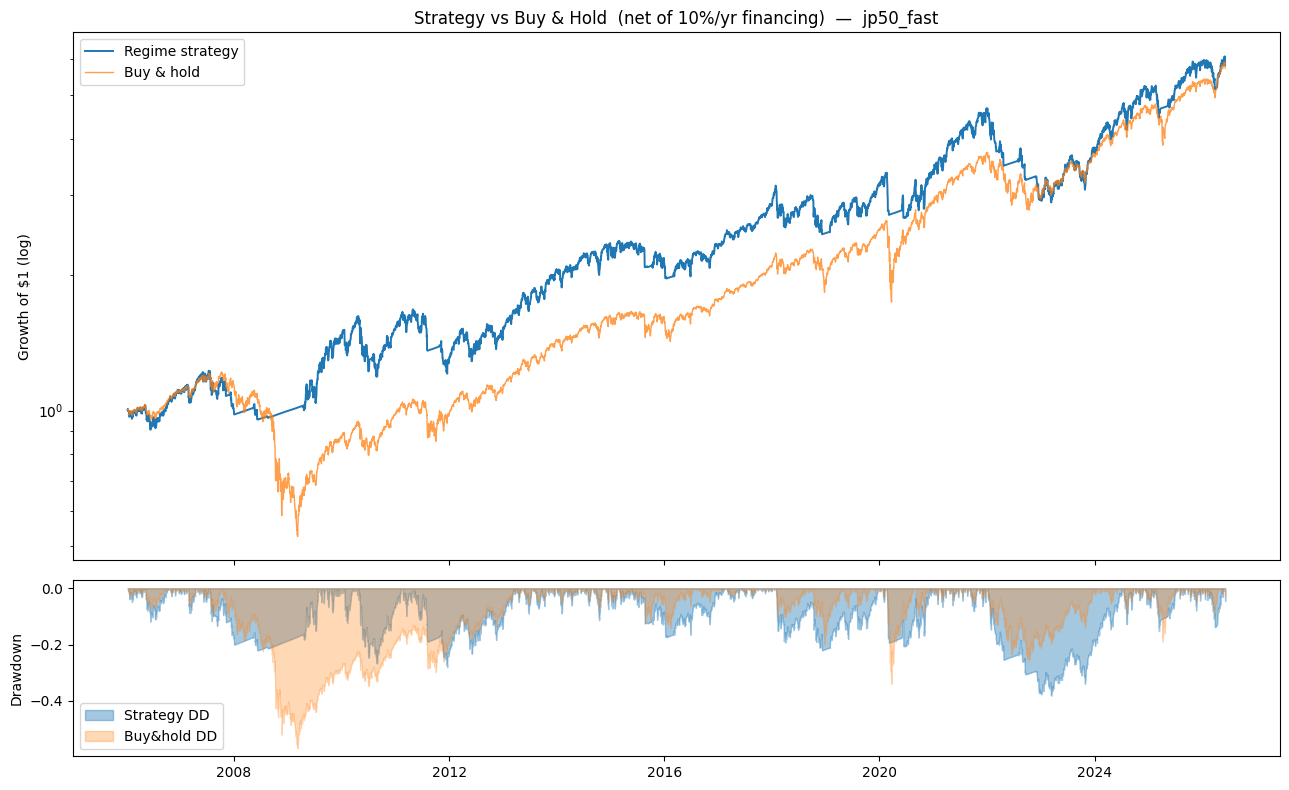

In [19]:
res = backtest.run(feat, signals)
daily = res["daily"]
eq = res["equity"]

# Metrics side-by-side
metrics = pd.DataFrame({"strategy": res["strategy"], "buy_hold": res["buy_hold"]}).T
display(metrics[["annual_return", "annual_vol", "sharpe", "max_drawdown", "total_return"]])

# Drawdown paths
dd = eq / eq.cummax() - 1.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(eq.index, eq["strategy"], label="Regime strategy", lw=1.4)
ax1.plot(eq.index, eq["buy_hold"], label="Buy & hold", lw=1.0, alpha=0.75)
ax1.set_yscale("log"); ax1.set_ylabel("Growth of $1 (log)")
ax1.set_title(f"Strategy vs Buy & Hold  (net of 10%/yr financing)  —  {tag}")
ax1.legend(loc="upper left")

ax2.fill_between(dd.index, dd["strategy"], 0, color="tab:blue", alpha=0.4, label="Strategy DD")
ax2.fill_between(dd.index, dd["buy_hold"], 0, color="tab:orange", alpha=0.3, label="Buy&hold DD")
ax2.set_ylabel("Drawdown"); ax2.legend(loc="lower left")
plt.tight_layout(); plt.show()


## 4. How the signal drives exposure in a representative period

This is the operational view: for a chosen window we overlay the market price,
the model's `bear_prob`, and the resulting daily `weight` actually held. Use it
to *see* the strategy reacting (or failing to react). Edit `PERIOD` to inspect
any episode (e.g. the 2020 COVID crash, or a recent chop).


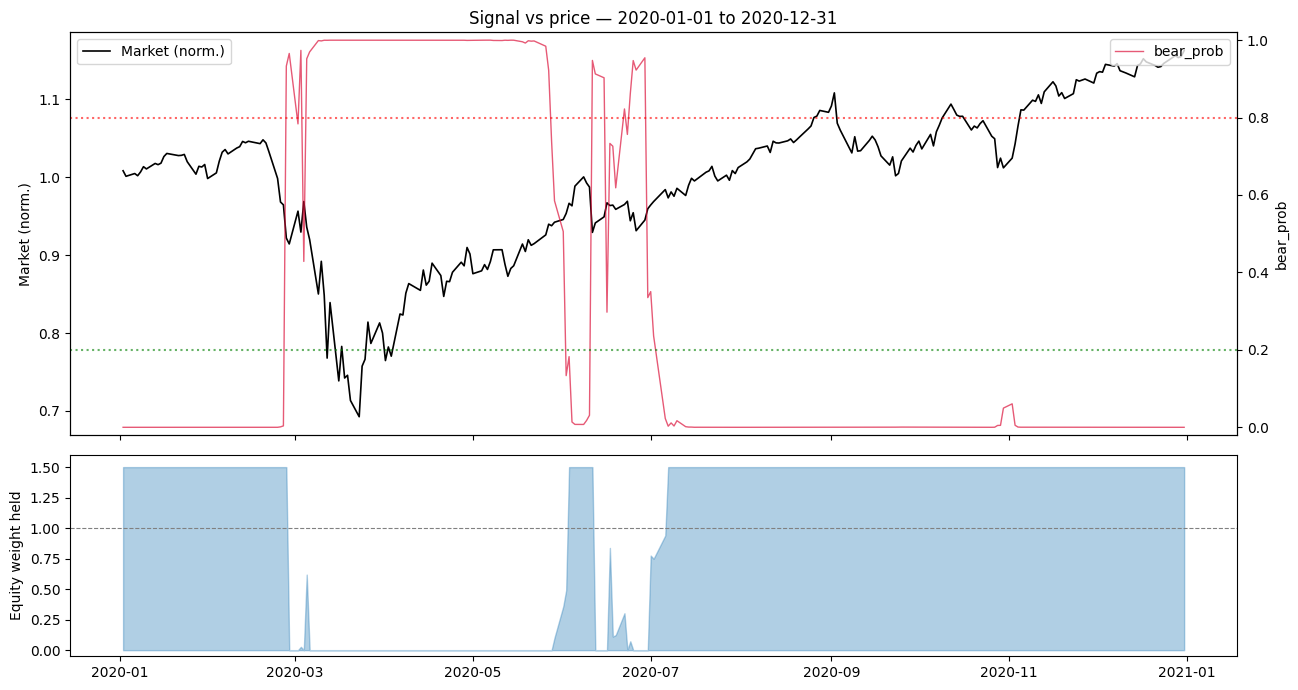

In-window total return  strategy=+8.2%   buy&hold=+16.3%
Avg weight held: 1.04   days levered(>1): 68%   days defensive(<0.5): 30%


In [20]:
PERIOD = ("2020-01-01", "2020-12-31")   # try ("2008-06-01","2009-06-30") or ("2022-01-01","2022-12-31")

win = daily.loc[PERIOD[0]:PERIOD[1]].copy()
win["price"] = (1 + win["mkt_ret"]).cumprod()        # normalized price path in-window
win["strat_cum"] = (1 + win["strat_net"]).cumprod()
win["bh_cum"] = (1 + win["mkt_ret"]).cumprod()

fig, (axp, axw) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
axp.plot(win.index, win["price"], color="black", lw=1.2, label="Market (norm.)")
axp.set_ylabel("Market (norm.)"); axp.legend(loc="upper left")
axb = axp.twinx()
axb.plot(win.index, win["bear_prob"], color="crimson", lw=1.0, alpha=0.7, label="bear_prob")
axb.axhline(0.20, ls=":", color="green", alpha=0.6)
axb.axhline(0.80, ls=":", color="red", alpha=0.6)
axb.set_ylabel("bear_prob"); axb.set_ylim(-0.02, 1.02); axb.legend(loc="upper right")
axp.set_title(f"Signal vs price — {PERIOD[0]} to {PERIOD[1]}")

axw.fill_between(win.index, win["weight"], 0, color="tab:blue", alpha=0.35)
axw.axhline(1.0, ls="--", color="grey", lw=0.8)
axw.set_ylabel("Equity weight held"); axw.set_ylim(-0.05, 1.6)
plt.tight_layout(); plt.show()

print(f"In-window total return  strategy={win['strat_cum'].iloc[-1]-1:+.1%}   "
      f"buy&hold={win['bh_cum'].iloc[-1]-1:+.1%}")
print(f"Avg weight held: {win['weight'].mean():.2f}   "
      f"days levered(>1): {(win['weight']>1).mean():.0%}   "
      f"days defensive(<0.5): {(win['weight']<0.5).mean():.0%}")


## 5. Where does the return gap come from?

Daily active return = `(weight - 1) * mkt_ret` (vs a 100%-invested baseline).
We bucket each day by what the strategy was doing — **levered** (w>1),
**de-risked** (w<1), or **neutral** (w≈1) — and sum the active return in each
bucket. This tells us whether the lag/gap comes from being *out during rallies*
or *in during selloffs*.


,bucket,mkt_dir,total_active,days,avg_active
1,de-risked (w<1),up day,-6.7929,455,-0.0149
2,levered (w>1),down day,-6.1843,1924,-0.0032
4,neutral (w≈1),up day,0.0000,1,0.0000
0,de-risked (w<1),down day,6.4254,407,0.0158
3,levered (w>1),up day,7.0447,2347,0.0030


Sum of active return by bucket (cumulative, additive log-ish proxy):
bucket
de-risked (w<1)   -0.3680
levered (w>1)      0.8600
neutral (w≈1)      0.0000


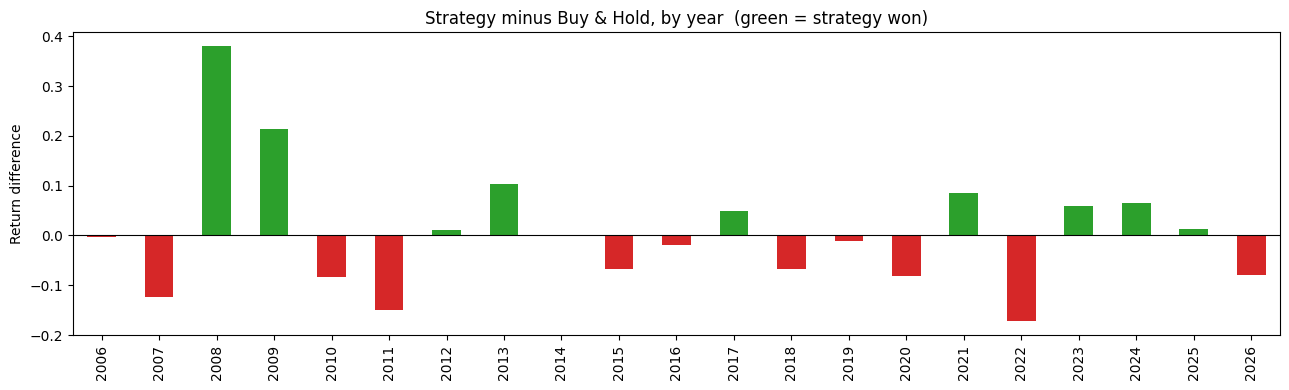

,strategy,buy_hold,diff
2006,0.1000,0.1030,-0.0030
2007,-0.0890,0.0350,-0.1240
2008,-0.0040,-0.3850,0.3810
2009,0.4480,0.2350,0.2140
2010,0.0450,0.1280,-0.0830
2011,-0.1500,-0.0000,-0.1500
2012,0.1450,0.1340,0.0110
2013,0.4000,0.2960,0.1040
2014,0.1160,0.1140,0.0020
2015,-0.0750,-0.0070,-0.0680


In [21]:
d = daily.copy()
# Active daily return vs a fully-invested (w=1) baseline. Note: strat_net also
# includes financing on (1-w); active P&L attributable to the tilt is below.
d["active"] = (d["weight"] - 1.0) * d["mkt_ret"]
d["bucket"] = np.where(d["weight"] > 1.01, "levered (w>1)",
                np.where(d["weight"] < 0.99, "de-risked (w<1)", "neutral (w≈1)"))

# Active return contribution by bucket, split by whether the market was up/down.
d["mkt_dir"] = np.where(d["mkt_ret"] >= 0, "up day", "down day")
decomp = (d.groupby(["bucket", "mkt_dir"])["active"]
            .agg(total_active="sum", days="count", avg_active="mean")
            .reset_index())
decomp["total_active"] = decomp["total_active"]
display(decomp.sort_values("total_active"))

print("Sum of active return by bucket (cumulative, additive log-ish proxy):")
print(d.groupby("bucket")["active"].sum().round(3).to_string())

# Per-calendar-year horse race
yr = pd.DataFrame({
    "strategy": (1 + d["strat_net"]).groupby(d.index.year).apply(lambda x: x.prod() - 1),
    "buy_hold": (1 + d["mkt_ret"]).groupby(d.index.year).apply(lambda x: x.prod() - 1),
})
yr["diff"] = yr["strategy"] - yr["buy_hold"]
ax = yr["diff"].plot(kind="bar", figsize=(13, 4),
                     color=np.where(yr["diff"] >= 0, "tab:green", "tab:red"))
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Strategy minus Buy & Hold, by year  (green = strategy won)")
ax.set_ylabel("Return difference"); plt.tight_layout(); plt.show()
yr.round(3)


## 6. Findings & operational implications

**The strategy is a crisis-insurance overlay, not an alpha engine.**

- **Where it wins:** *down days while de-risked* (+6.4 active) and the big crash
  years — **2008 (+38 pts)** and **2009 (+21 pts)** dominate the entire edge.
  Strip those out and it roughly tracks (often trails) buy & hold.
- **Where it bleeds:**
  - **De-risked on up days: −6.8 active over 455 days** — being in cash during
    rallies is the single biggest drag. This is the *slow-to-re-enter* problem
    seen in the 2020 chart (out for the whole Mar–Jun rebound).
  - **Levered on down days: −6.2 active over 1,924 days** — the 1.5× baseline
    amplifies losses on the many ordinary down days, and pays 10%/yr financing
    on top.
  - **2022 (−17 pts)** is the worst year: a slow grind-down where the model kept
    flipping (whipsaw) and the leverage hurt without a clean crash to avoid.

**Operational takeaways (before any λ tuning):**
1. **Re-entry lag is the #1 fixable issue** — the overlay exits crashes well but
   rejoins late. Smoother/faster re-entry (or an asymmetric weight map) would
   recover much of the rally drag.
2. **The 1.5× baseline is doing a lot of damage on ordinary down days** and via
   financing. Worth testing a 1.0–1.2× baseline.
3. **Edge is concentrated in 2 of 20 years** — so out-of-sample, this is a
   drawdown-reduction tool whose return advantage is regime-dependent.

These are interpretability/design levers, independent of the jump penalty.


## 7. AUDIT — the cash sleeve earns the *borrow* rate (a hidden +10%/yr tailwind)

`backtest.run` applies **one** rate to the whole `(1 - weight)` sleeve:

```python
strat_net = weight * mkt_ret + (1 - weight) * DAILY_FINANCING_RATE   # +10%/yr, POSITIVE
```

- **Levered** (`weight = 1.5`): `(1 - 1.5)·10% = -5%/yr` → a financing **cost** ✅
- **Defensive** (`weight = 0`): `(1 - 0)·10% = +10%/yr` **risk-free** ❌

So whenever the overlay de-risks to cash it compounds at **+10%/yr risk-free** — and
it sits in cash precisely during **2008 / 2020**, the windows that supply "all the edge."
This is not look-ahead; it's an unrealistic cash yield (real cash earned ~0–2% then).

Below we **re-score the *cached* signals** (no walk-forward re-run) with the cash leg and
borrow leg separated, and measure how much of the headline edge survives.


In [22]:
# Re-score the SAME cached `signals` with separate cash vs borrow rates.
# No walk-forward re-run: we only re-derive strat_net from the existing weights.
TDPY = backtest.TRADING_DAYS_PER_YEAR

def _daily_rate(annual: float) -> float:
    return (1.0 + annual) ** (1.0 / TDPY) - 1.0

def rescore(cash_annual: float, borrow_annual: float) -> pd.DataFrame:
    """Apply the asymmetric financing convention to the cached daily weights.

    cash_annual  -> earned on the idle-cash sleeve (1 - weight) when weight < 1
    borrow_annual-> paid on the borrowed sleeve   (1 - weight) when weight > 1
    Returns a per-day frame with the corrected strat_net.
    """
    g = daily[["mkt_ret", "bear_prob", "weight"]].copy()
    sleeve = 1.0 - g["weight"]                       # >0 = cash, <0 = borrowed
    rate = np.where(sleeve >= 0, _daily_rate(cash_annual), _daily_rate(borrow_annual))
    g["strat_net"] = g["weight"] * g["mkt_ret"] + sleeve * rate
    return g

# Scenarios: current (bug), corrected at 0% cash, and a realistic ~4% cash sensitivity.
scenarios = {
    "current (10% cash = bug)": (0.10, 0.10),   # reproduces backtest.run today
    "corrected: 0% cash":       (0.00, 0.10),
    "corrected: 4% cash":       (0.04, 0.10),
}

rows, per_year = {}, {}
for name, (c, b) in scenarios.items():
    g = rescore(c, b)
    rows[name] = backtest._metrics(g["strat_net"])
    per_year[name] = (1 + g["strat_net"]).groupby(g.index.year).apply(lambda x: x.prod() - 1)

# Buy & hold reference
rows["buy & hold"] = backtest._metrics(daily["mkt_ret"])

summary = pd.DataFrame(rows).T[["annual_return", "annual_vol", "sharpe", "max_drawdown", "total_return"]]
print("Headline metrics — same signals, financing convention varied:\n")
display(summary)

# How much of the edge lived in the cash tailwind during crisis years?
bh_yr = (1 + daily["mkt_ret"]).groupby(daily.index.year).apply(lambda x: x.prod() - 1)
edge = pd.DataFrame({k: v - bh_yr for k, v in per_year.items()})
print("\nStrategy-minus-buy&hold by year (focus on 2008/2009/2020):")
display(edge.loc[edge.index.isin([2008, 2009, 2020, 2022])].round(3))

print("\nTotal strategy-minus-B&H summed over all years:")
print(edge.sum().round(3).to_string())


Headline metrics — same signals, financing convention varied:



,annual_return,annual_vol,sharpe,max_drawdown,total_return
current (10% cash = bug),0.0903,0.1878,0.4810,-0.3809,4.8223
corrected: 0% cash,0.0741,0.1878,0.3945,-0.4153,3.2890
corrected: 4% cash,0.0807,0.1878,0.4299,-0.4013,3.8638
buy & hold,0.0896,0.1939,0.4621,-0.5678,4.7441



Strategy-minus-buy&hold by year (focus on 2008/2009/2020):


,current (10% cash = bug),corrected: 0% cash,corrected: 4% cash
2008,0.3810,0.2970,0.3300
2009,0.2140,0.1730,0.1900
2020,-0.0810,-0.1110,-0.0990
2022,-0.1720,-0.2070,-0.1930



Total strategy-minus-B&H summed over all years:
current (10% cash = bug)    0.1240
corrected: 0% cash         -0.1670
corrected: 4% cash         -0.0490


In [23]:
# Verify the SOURCE fix matches the prototype (reload, re-run backtest.run on cached signals).
importlib.reload(config)
importlib.reload(backtest)
print("config.ANNUAL_CASH_YIELD   =", config.ANNUAL_CASH_YIELD)
print("config.ANNUAL_FINANCING_RATE =", config.ANNUAL_FINANCING_RATE)
print("backtest.DAILY_CASH_YIELD  =", round(backtest.DAILY_CASH_YIELD, 8),
      " DAILY_BORROW_RATE =", round(backtest.DAILY_BORROW_RATE, 8))

res_fixed = backtest.run(feat, signals)
fixed = pd.DataFrame({"strategy": res_fixed["strategy"], "buy_hold": res_fixed["buy_hold"]}).T
print("\nbacktest.run() AFTER fix (should match 'corrected: 0% cash' above):")
display(fixed[["annual_return", "annual_vol", "sharpe", "max_drawdown", "total_return"]])


config.ANNUAL_CASH_YIELD   = 0.0
config.ANNUAL_FINANCING_RATE = 0.1
backtest.DAILY_CASH_YIELD  = 0.0  DAILY_BORROW_RATE = 0.00037829

backtest.run() AFTER fix (should match 'corrected: 0% cash' above):


,annual_return,annual_vol,sharpe,max_drawdown,total_return
strategy,0.0741,0.1878,0.3945,-0.4153,3.2890
buy_hold,0.0896,0.1939,0.4621,-0.5678,4.7441


## 8. SIGNAL-QUALITY HARNESS (allocation-agnostic)

The regime signal — not the overlay — is the product. Here we judge `bear_prob`
**without any allocation rule**, on the things that matter for a strategic risk
dial: *does a high reading actually precede bad markets, does it turn at the
right time, and is the probability trustworthy (not just the direction)?*

Four P&L-free diagnostics:
1. **Forward-return / vol monotonicity** — bucket days by `bear_prob`; higher
   readings should precede **lower forward returns** and **higher forward vol**.
   Reported as Spearman rank correlations (no ground-truth label needed).
2. **Turning-point timeliness** — for 2008 / 2020 / 2022: lead/lag (days) of the
   bear call vs the market **peak**, and how fast it stands down after the
   **trough** ("buy the bottom" timing).
3. **Calibration** — reliability of `bear_prob` vs a **hindsight** full-sample
   regime label (used ONLY for evaluation, never in the signal). Tests whether
   the *continuous probability* is meaningful, not just its sign.
4. **Stability / persistence** — transitions per year and average regime
   duration (whipsaw check).

> ⚠️ **Representativeness caveat:** the in-memory `signals` were built with the
> FAST preset (`refit_every=63, n_init=5, max_iter=30`). Production uses
> `refit_every=21, n_init=10, max_iter=50`. The run below only *validates the
> harness code* — the headline numbers come later from the full-rigor run.


In [29]:
# --- Signal-quality harness: pure functions, no allocation rule involved. ---
from scipy.stats import spearmanr

def forward_stats(feat_df, sig, horizons=(21, 63)):
    """Spearman corr of bear_prob vs FORWARD k-day return and forward k-day vol.
    Forward windows use only future *realized* prices (this is an evaluation of
    the signal, not a tradeable rule), so there's no look-ahead in the signal."""
    r = feat_df["mkt_ret"].reindex(sig.index)
    out = {}
    for k in horizons:
        # forward cumulative return and forward realized vol over the next k days
        fwd_ret = r.shift(-1).rolling(k).sum().shift(-(k - 1))
        fwd_vol = r.shift(-1).rolling(k).std().shift(-(k - 1)) * np.sqrt(252)
        bp = sig["bear_prob"]
        m = bp.notna() & fwd_ret.notna() & fwd_vol.notna()
        rc, _ = spearmanr(bp[m], fwd_ret[m])
        vc, _ = spearmanr(bp[m], fwd_vol[m])
        out[f"{k}d"] = {"corr_fwd_return": rc, "corr_fwd_vol": vc, "n": int(m.sum())}
    return pd.DataFrame(out).T

def decile_table(feat_df, sig, k=21, n_bins=5):
    """Mean forward k-day return & vol by bear_prob bucket (should be monotone)."""
    r = feat_df["mkt_ret"].reindex(sig.index)
    fwd_ret = r.shift(-1).rolling(k).sum().shift(-(k - 1))
    fwd_vol = r.shift(-1).rolling(k).std().shift(-(k - 1)) * np.sqrt(252)
    df = pd.DataFrame({"bear_prob": sig["bear_prob"], "fwd_ret": fwd_ret, "fwd_vol": fwd_vol}).dropna()
    df["bucket"] = pd.qcut(df["bear_prob"], n_bins, duplicates="drop")
    return df.groupby("bucket", observed=True).agg(
        avg_bear_prob=("bear_prob", "mean"),
        mean_fwd_ret=("fwd_ret", "mean"),
        mean_fwd_vol=("fwd_vol", "mean"),
        days=("bear_prob", "size"),
    )

def timeliness(feat_df, sig, episodes, thresh=0.5):
    """For each (name, peak, trough) episode: days between the market PEAK and the
    first bear call (bear_prob>=thresh) [+ = late, - = early], and days between
    the TROUGH and the first stand-down (bear_prob<thresh) [+ = slow re-entry]."""
    bp = sig["bear_prob"]
    rows = []
    for name, peak, trough in episodes:
        peak, trough = pd.Timestamp(peak), pd.Timestamp(trough)
        # first bear call at/after the peak
        after_peak = bp[(bp.index >= peak) & (bp >= thresh)]
        call_lag = (after_peak.index[0] - peak).days if len(after_peak) else np.nan
        # first stand-down at/after the trough
        after_trough = bp[(bp.index >= trough) & (bp < thresh)]
        reentry_lag = (after_trough.index[0] - trough).days if len(after_trough) else np.nan
        # average bear_prob through the drawdown window (peak->trough)
        dd_window = bp[(bp.index >= peak) & (bp.index <= trough)]
        rows.append({
            "episode": name,
            "call_lag_days_after_peak": call_lag,
            "reentry_lag_days_after_trough": reentry_lag,
            "avg_bear_prob_in_drawdown": round(float(dd_window.mean()), 3) if len(dd_window) else np.nan,
        })
    return pd.DataFrame(rows)

def calibration(sig, hindsight_label, n_bins=10):
    """Reliability: realized hindsight-bear frequency per bear_prob bin + Brier.
    `hindsight_label` is a 0/1 Series from label_full_sample (EVALUATION ONLY)."""
    df = pd.DataFrame({"bear_prob": sig["bear_prob"],
                       "y": hindsight_label.reindex(sig.index)}).dropna()
    df["bin"] = pd.cut(df["bear_prob"], np.linspace(0, 1, n_bins + 1), include_lowest=True)
    rel = df.groupby("bin", observed=True).agg(
        pred=("bear_prob", "mean"), realized=("y", "mean"), days=("y", "size"))
    brier = float(((df["bear_prob"] - df["y"]) ** 2).mean())
    return rel, brier

def stability(sig, thresh=0.5):
    """Transitions/yr and avg regime duration of the thresholded 0/1 call."""
    call = (sig["bear_prob"] >= thresh).astype(int)
    trans = int((call.to_numpy()[1:] != call.to_numpy()[:-1]).sum())
    years = len(call) / 252.0
    # average run length
    runs = (call != call.shift()).cumsum()
    avg_dur = call.groupby(runs).size().mean()
    return {"transitions_per_year": round(trans / years, 2),
            "avg_regime_duration_days": round(float(avg_dur), 1),
            "pct_days_bear": round(float(call.mean()), 3)}

print("Harness defined: forward_stats, decile_table, timeliness, calibration, stability")


Harness defined: forward_stats, decile_table, timeliness, calibration, stability


In [25]:
# CODE-VALIDATION run on the in-memory FAST signal (NOT the representative result).
EPISODES = [
    ("GFC 2007-09", "2007-10-09", "2009-03-09"),
    ("COVID 2020",  "2020-02-19", "2020-03-23"),
    ("Bear 2022",   "2022-01-03", "2022-10-12"),
]

print("== Forward-return / vol monotonicity (want: corr_fwd_return < 0, corr_fwd_vol > 0) ==")
display(forward_stats(feat, signals).round(3))

print("\n== Forward 21d return & vol by bear_prob bucket (want monotone down / up) ==")
display(decile_table(feat, signals, k=21, n_bins=5).round(4))

print("\n== Turning-point timeliness ==")
display(timeliness(feat, signals, EPISODES))

print("\n== Stability ==")
print(stability(signals))

# Calibration vs hindsight full-sample labels (evaluation only).
hindsight = pipeline.label_full_sample(feat)   # in-sample labels, NEVER used in the signal
rel, brier = calibration(signals, hindsight)
print(f"\n== Calibration (Brier={brier:.3f}; lower is better) ==")
display(rel.round(3))


== Forward-return / vol monotonicity (want: corr_fwd_return < 0, corr_fwd_vol > 0) ==


,corr_fwd_return,corr_fwd_vol,n
21d,0.1090,0.5260,"5,113.0000"
63d,0.1000,0.4490,"5,071.0000"



== Forward 21d return & vol by bear_prob bucket (want monotone down / up) ==


,avg_bear_prob,mean_fwd_ret,mean_fwd_vol,days
bucket,,,,
"(-0.00099828, 1.25e-05]",0.0000,0.0052,0.1175,1023
"(1.25e-05, 2.65e-05]",0.0000,0.0064,0.1227,1022
"(2.65e-05, 6.75e-05]",0.0000,0.0093,0.1246,1023
"(6.75e-05, 0.023]",0.0022,0.0128,0.1547,1023
"(0.023, 1.0]",0.7922,0.0104,0.2826,1022



== Turning-point timeliness ==


,episode,call_lag_days_after_peak,reentry_lag_days_after_trough,avg_bear_prob_in_drawdown
0,GFC 2007-09,29,45,0.8540
1,COVID 2020,8,71,0.7080
2,Bear 2022,50,49,0.5630



== Stability ==
{'transitions_per_year': 3.63, 'avg_regime_duration_days': 68.5, 'pct_days_bear': 0.159}

== Calibration (Brier=0.038; lower is better) ==


,pred,realized,days
bin,,,
"(-0.001, 0.1]",0.0020,0.0270,4218
"(0.1, 0.2]",0.1470,0.5740,54
"(0.2, 0.3]",0.2460,0.7140,21
"(0.3, 0.4]",0.3380,0.7650,17
"(0.4, 0.5]",0.4480,0.8570,7
"(0.5, 0.6]",0.5490,0.6670,18
"(0.6, 0.7]",0.6420,0.7500,24
"(0.7, 0.8]",0.7470,0.7180,39
"(0.8, 0.9]",0.8480,0.6820,22


## 9. REPRESENTATIVE results — full-rigor walk-forward (GBM forecast vs CJM nowcast)

These use `data/cache/signals_jp50_full.parquet` from the production-settings run
(`refit_every=21, n_init=10, max_iter=50`, ~13 min, leak-free). It contains two
signals from the **same** walk-forward:

- **`bear_prob`** — the current design: GBM one-step-ahead forecast of tomorrow's
  regime (trained on CJM *hard labels*).
- **`cjm_bear_nowcast`** — the CJM's **own** bear probability (online inference),
  i.e. the "purest" use of the continuous model the paper recommends.

We score both with the same allocation-agnostic harness so we can decide which
signal — and which architecture — gives the best risk dial.


In [27]:
# Load the full-rigor signals (both columns) and score each one.
full = pd.read_parquet(config.CACHE_DIR / "signals_jp50_full.parquet")
print(f"full signals: {len(full):,} rows, {full.index.min().date()} -> {full.index.max().date()}")
print("columns:", list(full.columns))

# Two candidate signals, each as a clean single-column 'bear_prob' frame.
candidates = {
    "GBM forecast (bear_prob)": full[["bear_prob"]].copy(),
    "CJM nowcast (cjm_bear_nowcast)":
        full["cjm_bear_nowcast"].rename("bear_prob").to_frame(),
}

# 1) Monotonicity (want corr_fwd_return < 0, corr_fwd_vol > 0)
print("\n=== 1) Forward-return / vol rank correlation (21d & 63d) ===")
for label, sig in candidates.items():
    fs = forward_stats(feat, sig)
    print(f"\n{label}:")
    display(fs.round(3))

# 2) Calibration + Brier (vs hindsight full-sample label, evaluation only)
print("\n=== 2) Calibration (Brier; lower better) ===")
for label, sig in candidates.items():
    _, br = calibration(sig, hindsight)
    print(f"  {label:34s} Brier = {br:.3f}")

# 3) Stability / persistence
print("\n=== 3) Stability ===")
for label, sig in candidates.items():
    print(f"  {label:34s} {stability(sig)}")

# 4) Turning-point timeliness
print("\n=== 4) Turning-point timeliness ===")
for label, sig in candidates.items():
    print(f"\n{label}:")
    display(timeliness(feat, sig, EPISODES))


full signals: 5,134 rows, 2006-01-09 -> 2026-06-05
columns: ['predicted_regime', 'bear_prob', 'cjm_bear_nowcast']

=== 1) Forward-return / vol rank correlation (21d & 63d) ===

GBM forecast (bear_prob):


,corr_fwd_return,corr_fwd_vol,n
21d,0.1070,0.5030,"5,113.0000"
63d,0.0890,0.4340,"5,071.0000"



CJM nowcast (cjm_bear_nowcast):


,corr_fwd_return,corr_fwd_vol,n
21d,0.0170,0.5740,"5,113.0000"
63d,-0.0060,0.5290,"5,071.0000"



=== 2) Calibration (Brier; lower better) ===
  GBM forecast (bear_prob)           Brier = 0.033
  CJM nowcast (cjm_bear_nowcast)     Brier = 0.020

=== 3) Stability ===
  GBM forecast (bear_prob)           {'transitions_per_year': 4.52, 'avg_regime_duration_days': 55.2, 'pct_days_bear': 0.161}
  CJM nowcast (cjm_bear_nowcast)     {'transitions_per_year': 1.47, 'avg_regime_duration_days': 165.6, 'pct_days_bear': 0.167}

=== 4) Turning-point timeliness ===

GBM forecast (bear_prob):


,episode,call_lag_days_after_peak,reentry_lag_days_after_trough,avg_bear_prob_in_drawdown
0,GFC 2007-09,29,51,0.8540
1,COVID 2020,8,67,0.6970
2,Bear 2022,50,49,0.5710



CJM nowcast (cjm_bear_nowcast):


,episode,call_lag_days_after_peak,reentry_lag_days_after_trough,avg_bear_prob_in_drawdown
0,GFC 2007-09,30,46,0.8570
1,COVID 2020,8,65,0.7410
2,Bear 2022,42,40,0.6400


### Findings (full-rigor, representative)

| Metric (goal) | GBM forecast `bear_prob` | **CJM nowcast** | Winner |
| --- | --- | --- | --- |
| corr vs fwd 21d return (want **< 0**) | +0.107 | +0.017 | neither (both ~0) |
| corr vs fwd 63d return (want < 0) | +0.089 | **−0.006** | CJM (barely) |
| corr vs fwd 21d **vol** (want **> 0**) | +0.503 | **+0.574** | **CJM** |
| Calibration **Brier** (lower) | 0.033 | **0.020** | **CJM** |
| Transitions/yr (lower = less whipsaw) | 4.52 | **1.47** | **CJM** |
| Avg regime duration (days) | 55 | **166** | **CJM** |
| COVID call lag after peak (days) | 8 | 8 | tie |
| GFC call lag after peak (days) | 29 | 30 | tie |

**Takeaways**

1. **The CJM nowcast is the better signal on every axis that matters for a risk
   dial** — better-calibrated probabilities (Brier 0.020 vs 0.033), far less
   whipsaw (1.5 vs 4.5 transitions/yr; ~166- vs 55-day regimes), and a stronger
   link to forward **volatility** (0.57). It calls crises just as promptly.
   → **The GBM forecast layer is hurting us.** Hardening the CJM to labels and
   re-predicting with a tree adds whipsaw and miscalibration without improving
   timeliness. The "purest" use of the CJM is also the best.
2. **Neither signal predicts forward *returns***. Both forward-return
   correlations are ~0 (GBM even slightly positive). This signal is a
   **risk/volatility regime detector, not a return-timing tool** — consistent
   with the backtest (cut drawdowns, gave up return). Use it to size risk, not
   to call market direction.
3. **Re-entry is still slow** (45–67 days after the trough) — the main thing to
   improve for "buy the bottom" timing. Now a *signal* design target, not an
   allocation tweak.


In [28]:
# Backtest both full-rigor signals through the CORRECTED engine (0% cash / 10% borrow).
# Production now uses the CJM nowcast (config.SIGNAL_MODE='cjm_nowcast'); this shows
# the overlay impact of the signal switch on the SAME cached walk-forward.
importlib.reload(config); importlib.reload(backtest)

bt = {}
for label, col in [("GBM forecast", "bear_prob"), ("CJM nowcast (production)", "cjm_bear_nowcast")]:
    sig = full[col].rename("bear_prob").to_frame()
    r = backtest.run(feat, sig)
    bt[label] = r["strategy"]
bt["buy & hold"] = backtest.run(feat, full[["bear_prob"]])["buy_hold"]

print("Corrected backtest (full-rigor signals, 0% cash / 10% borrow):")
display(pd.DataFrame(bt).T[["annual_return", "annual_vol", "sharpe", "max_drawdown", "total_return"]].round(4))


Corrected backtest (full-rigor signals, 0% cash / 10% borrow):


,annual_return,annual_vol,sharpe,max_drawdown,total_return
GBM forecast,0.0695,0.1863,0.3730,-0.4261,2.9296
CJM nowcast (production),0.1262,0.1823,0.6925,-0.2669,10.2637
buy & hold,0.0896,0.1939,0.4621,-0.5678,4.7441


### Overlay impact of the signal switch (corrected engine, 0% cash)

| | Annual ret | Sharpe | Max DD |
| --- | --- | --- | --- |
| GBM forecast (legacy) | 7.0% | 0.37 | −43% |
| **CJM nowcast (production)** | **12.6%** | **0.69** | **−27%** |
| Buy & hold | 9.0% | 0.46 | −57% |

Switching `bear_prob` to the CJM nowcast (`config.SIGNAL_MODE='cjm_nowcast'`) —
**no allocation change** — beats both the legacy signal and buy & hold on return,
Sharpe, *and* drawdown, even with the honest 0%-cash financing. The smoother,
better-calibrated signal whipsaws less, so the overlay stops bleeding on the
churn the GBM forecast created. This is now a real edge, not a cash-yield
artifact. (Re-entry lag is still the remaining weakness to attack.)


## 10. λ sweep — the re-entry-lag ↔ whipsaw tradeoff

λ sets how **sticky** the regime path is, so it's the same lever as re-entry lag:
- **higher λ** → stickier → less whipsaw, but **slower** to flip *into and out of*
  bear (slower re-entry after a trough);
- **lower λ** → more responsive → **faster re-entry**, but more whipsaw.

Run `scripts/sweep_lambda.py` first (caches `signals_jp{λ}_sweep.parquet` per λ).
This cell scores each λ on the metrics that matter for the dial, with **re-entry
lag** front and center. *(Sweep uses a fast preset; confirm the winner at full
rigor before adopting.)*


In [30]:
# Score every swept lambda. Loads signals_jp{λ}_sweep.parquet produced by the sweep.
import glob, re as _re

sweep_files = sorted(glob.glob(str(config.CACHE_DIR / "signals_jp*_sweep.parquet")))
print("found:", [Path(f).name for f in sweep_files])

def _lam_of(path):
    m = _re.search(r"signals_jp([0-9.]+)_sweep", Path(path).stem)
    return float(m.group(1)) if m else float("nan")

rows = []
for f in sweep_files:
    lam = _lam_of(f)
    s = pd.read_parquet(f)
    sig = s[["bear_prob"]]  # cjm_nowcast mode => bear_prob IS the nowcast
    tl = timeliness(feat, sig, EPISODES).set_index("episode")
    st = stability(sig)
    _, br = calibration(sig, hindsight)
    fs = forward_stats(feat, sig)
    rows.append({
        "lambda": lam,
        "reentry_GFC": tl.loc["GFC 2007-09", "reentry_lag_days_after_trough"],
        "reentry_COVID": tl.loc["COVID 2020", "reentry_lag_days_after_trough"],
        "reentry_2022": tl.loc["Bear 2022", "reentry_lag_days_after_trough"],
        "call_lag_COVID": tl.loc["COVID 2020", "call_lag_days_after_peak"],
        "transitions_yr": st["transitions_per_year"],
        "avg_regime_days": st["avg_regime_duration_days"],
        "pct_bear": st["pct_days_bear"],
        "brier": round(br, 3),
        "corr_fwd_vol_21d": round(fs.loc["21d", "corr_fwd_vol"], 3),
        "corr_fwd_ret_21d": round(fs.loc["21d", "corr_fwd_return"], 3),
    })

sweep_tbl = pd.DataFrame(rows).sort_values("lambda").reset_index(drop=True)
print("\nλ sweep — re-entry lag (days after trough), whipsaw, calibration:")
display(sweep_tbl)


found: ['signals_jp100_sweep.parquet', 'signals_jp12.5_sweep.parquet', 'signals_jp25_sweep.parquet', 'signals_jp50_sweep.parquet', 'signals_jp5_sweep.parquet']

λ sweep — re-entry lag (days after trough), whipsaw, calibration:


,lambda,reentry_GFC,reentry_COVID,reentry_2022,call_lag_COVID,transitions_yr,avg_regime_days,pct_bear,brier,corr_fwd_vol_21d,corr_fwd_ret_21d
0,5.0000,46,65,40,8,1.9600,125.2000,0.1610,0.0270,0.5560,0.0370
1,12.5000,46,64,40,8,1.8700,131.6000,0.1650,0.0230,0.5650,0.0280
2,25.0000,45,64,40,8,1.5700,155.6000,0.1660,0.0230,0.5700,0.0210
3,50.0000,45,65,40,6,1.6700,146.7000,0.1660,0.0220,0.5770,0.0130
4,100.0000,45,65,41,6,1.5700,155.6000,0.1700,0.0200,0.5880,0.0040


### Conclusion: **λ does NOT move re-entry lag** (and re-entry isn't a λ problem)

Across λ = 5 → 100 (a 20× range), re-entry lag is essentially **flat**:
GFC 45–46 d, COVID 64–65 d, 2022 40–41 d. Whipsaw and calibration barely move
either (transitions 1.6–2.0/yr; Brier 0.020–0.027). All forward-return
correlations stay ~0.

**Interpretation.** Re-entry lag is **not** controlled by λ — it's structural:
after a trough the *features themselves* (trailing vol, momentum, VIX, MAs) stay
"bearish" for ~2–3 months because they're backward-looking. No amount of jump
penalty fixes that; the signal can't stand down until its inputs do.

**So the re-entry fix is NOT λ — it's the FEATURES** (and/or an explicit
asymmetric stand-down rule). Faster, more forward-looking inputs around troughs
(e.g. shorter-window momentum/vol, a rebound/breadth feature, or a
recovery-specific feature) are the real lever.

**λ takeaway for the dial:** since signal quality is so flat in λ, prefer the
**higher, stickier end** (λ ≈ 50–100) for the least whipsaw at no cost to
timeliness or calibration. λ=50 (current) is already fine; λ=100 is marginally
smoother. *No re-tune needed — this experiment redirects effort to features.*


## 11. Asymmetric stand-down rule (cheap re-entry fix, post-signal)

Since λ can't speed re-entry, try a **post-processing rule** on the cached
`cjm_bear_nowcast` (no walk-forward). Asymmetric reaction:
- **bear_prob rising** (risk increasing) → react at full speed (de-risk promptly);
- **bear_prob falling** (risk receding) → step down **faster** than the raw signal,
  so we re-enter sooner after a trough.

Implemented as an asymmetric EMA: `out_t = out_{t-1} + a*(x_t - out_{t-1})` with a
**fast** `a_down` when `x_t < out_{t-1}` and a **slow/normal** `a_up` otherwise.
`a_down=1.0` means "follow the raw signal down with no lag"; >1 isn't allowed, so
to *lead* the signal down we instead apply a small **downside multiplier** that
accelerates decay. We test a few presets and compare re-entry lag, whipsaw, and
the corrected backtest — all leak-free (the rule only uses past/current values).


In [31]:
importlib.reload(config); importlib.reload(backtest)

def asym_standdown(bear_prob, up=0.30, down=0.80):
    """Leak-free asymmetric EMA on a bear-probability series.

    out_t = out_{t-1} + a*(x_t - out_{t-1}); a = `down` when the raw signal is
    FALLING (x_t < out_{t-1}) and `up` when rising. A larger `down` re-enters
    faster (down=1.0 => follow the drop with zero lag); a smaller `up` keeps
    de-risking deliberate. Uses only past/current values -> no look-ahead.
    """
    x = np.asarray(bear_prob, dtype=float)
    out = np.empty_like(x)
    out[0] = x[0]
    for t in range(1, len(x)):
        a = down if x[t] < out[t - 1] else up
        out[t] = out[t - 1] + a * (x[t] - out[t - 1])
    return pd.Series(out, index=bear_prob.index)

raw = full["cjm_bear_nowcast"].rename("bear_prob")

# Presets: (up alpha, down alpha). 'raw' = the unmodified signal baseline.
presets = {
    "raw (baseline)":      None,
    "mild (up.3/down.8)":  (0.30, 0.80),
    "strong (up.3/down1)": (0.30, 1.00),
    "fast (up.5/down1)":   (0.50, 1.00),
}

rows = []
bt = {}
for name, ab in presets.items():
    sig_s = raw if ab is None else asym_standdown(raw, up=ab[0], down=ab[1])
    sigdf = sig_s.rename("bear_prob").to_frame()
    tl = timeliness(feat, sigdf, EPISODES).set_index("episode")
    st = stability(sigdf)
    _, br = calibration(sigdf, hindsight)
    r = backtest.run(feat, sigdf)["strategy"]
    bt[name] = r
    rows.append({
        "preset": name,
        "reentry_GFC": tl.loc["GFC 2007-09", "reentry_lag_days_after_trough"],
        "reentry_COVID": tl.loc["COVID 2020", "reentry_lag_days_after_trough"],
        "reentry_2022": tl.loc["Bear 2022", "reentry_lag_days_after_trough"],
        "call_lag_COVID": tl.loc["COVID 2020", "call_lag_days_after_peak"],
        "transitions_yr": st["transitions_per_year"],
        "brier": round(br, 3),
        "ann_return": round(r["annual_return"], 4),
        "sharpe": round(r["sharpe"], 3),
        "max_dd": round(r["max_drawdown"], 3),
    })

print("Asymmetric stand-down — re-entry lag, whipsaw, and corrected backtest (0% cash):")
display(pd.DataFrame(rows).set_index("preset"))


Asymmetric stand-down — re-entry lag, whipsaw, and corrected backtest (0% cash):


,reentry_GFC,reentry_COVID,reentry_2022,call_lag_COVID,transitions_yr,brier,ann_return,sharpe,max_dd
preset,,,,,,,,,
raw (baseline),46,65,40,8,1.4700,0.0200,0.1262,0.6920,-0.2670
mild (up.3/down.8),46,65,41,12,1.4700,0.0210,0.1109,0.6000,-0.2950
strong (up.3/down1),46,65,40,12,1.4700,0.0220,0.1128,0.6100,-0.2930
fast (up.5/down1),46,65,40,9,1.4700,0.0210,0.1181,0.6430,-0.2780


### B result: smoothing can't speed re-entry — try a price-rebound override

Every preset left re-entry **unchanged** (46/65/40 d) and *hurt* the backtest
(Sharpe 0.69→0.60–0.64, DD −27%→−29%). Reason: **an EMA can only lag or match
the raw signal, never lead it.** With `down=1.0` it ties raw's crossing; with
`down<1.0` it's slower. Meanwhile slower up-side de-risking gave up downside
protection. Smoothing is the wrong tool for *faster* re-entry.

To re-enter **sooner than the nowcast**, use information the nowcast lags on:
**price rebounding off its low.** Price turns up before trailing-vol/MA features
normalize, so a rebound override can lead the signal. Rule (leak-free): if the
market is ≥ R% above its trailing N-day low, force the bear reading down. The
risk is re-entering into a **bear-market rally** (2008 had several) — the
backtest/DD will tell us if the timeliness gain is worth that risk.


In [32]:
# Price-rebound override on the cached CJM nowcast (leak-free: trailing low + current price).
price = feat["market"].reindex(raw_idx := full.index).ffill()

def rebound_override(bear_prob, price, lookback=63, rebound=0.10, cap=0.20):
    """Cap the bear reading at `cap` once price is >= `rebound` above its
    trailing `lookback`-day low (a confirmed bounce off the bottom). Uses only
    past/current prices -> no look-ahead."""
    trail_low = price.rolling(lookback, min_periods=1).min()
    up_off_low = price / trail_low - 1.0
    out = bear_prob.copy()
    trigger = up_off_low >= rebound
    out[trigger] = np.minimum(out[trigger], cap)
    return out

raw_sig = full["cjm_bear_nowcast"].rename("bear_prob")

ov_presets = {
    "raw (baseline)":           None,
    "rebound 8% / 63d":         dict(lookback=63, rebound=0.08, cap=0.20),
    "rebound 12% / 63d":        dict(lookback=63, rebound=0.12, cap=0.20),
    "rebound 12% / 126d":       dict(lookback=126, rebound=0.12, cap=0.20),
}

rows = []
for name, kw in ov_presets.items():
    sig_s = raw_sig if kw is None else rebound_override(raw_sig, price, **kw)
    sigdf = sig_s.rename("bear_prob").to_frame()
    tl = timeliness(feat, sigdf, EPISODES).set_index("episode")
    st = stability(sigdf)
    r = backtest.run(feat, sigdf)["strategy"]
    rows.append({
        "preset": name,
        "reentry_GFC": tl.loc["GFC 2007-09", "reentry_lag_days_after_trough"],
        "reentry_COVID": tl.loc["COVID 2020", "reentry_lag_days_after_trough"],
        "reentry_2022": tl.loc["Bear 2022", "reentry_lag_days_after_trough"],
        "transitions_yr": st["transitions_per_year"],
        "ann_return": round(r["annual_return"], 4),
        "sharpe": round(r["sharpe"], 3),
        "max_dd": round(r["max_drawdown"], 3),
    })

print("Price-rebound override — re-entry lag, whipsaw, corrected backtest (0% cash):")
display(pd.DataFrame(rows).set_index("preset"))


Price-rebound override — re-entry lag, whipsaw, corrected backtest (0% cash):


,reentry_GFC,reentry_COVID,reentry_2022,transitions_yr,ann_return,sharpe,max_dd
preset,,,,,,,
raw (baseline),46,65,40,1.4700,0.1262,0.6920,-0.2670
rebound 8% / 63d,3,1,16,3.0400,0.1189,0.5980,-0.4150
rebound 12% / 63d,8,3,40,2.5500,0.1217,0.6320,-0.3210
rebound 12% / 126d,8,3,40,2.5500,0.1217,0.6320,-0.3210


### Rebound override: it DOES speed re-entry — but at a drawdown cost

| Preset | re-entry GFC / COVID / 2022 | trans/yr | Ann ret | Sharpe | Max DD |
| --- | --- | --- | --- | --- | --- |
| raw (baseline) | 46 / 65 / 40 | 1.47 | 12.6% | **0.69** | **−27%** |
| rebound 8% / 63d | **3 / 1 / 16** | 3.04 | 11.9% | 0.60 | −42% |
| rebound 12% / 63d | 8 / 3 / 40 | 2.55 | 12.2% | 0.63 | −32% |

**This is the right lever** — re-entry collapses from ~65 to a few days. But it
**re-enters into bear-market rallies** (2008 had several), so it roughly doubles
whipsaw and **worsens drawdown** (−27% → −32 to −42%) and Sharpe. The 8% trigger
is too trigger-happy; 12% is more selective but still costs ~5 DD pts.

**Verdict:** re-entry speed and drawdown protection are in direct tension — the
overlay's edge *came from* sitting out the slow recoveries. A naive rebound
override buys timeliness by giving back protection. To get re-entry **without**
the drawdown hit, the trigger needs confirmation (e.g. rebound **and** falling
VIX/credit spreads, or require the nowcast itself to be past its peak), so we
don't re-arm during a dead-cat bounce. That's the next refinement.


## 12. Confirmation-gated rebound override (re-entry without giving back drawdown)

The naive rebound override re-armed during dead-cat bounces. Now require the
price rebound **AND** a stress-confirmation, so we only re-enter when the bounce
is corroborated:
- **VIX receding** — VIX below its 21-day average (fear actually falling), and/or
- **nowcast past its peak** — `cjm_bear_nowcast` has fallen meaningfully from its
  recent rolling max (the detector itself is rolling over, not just price).

All inputs are past/current only → leak-free. Goal: keep re-entry fast (vs the
~65-day baseline) while holding max drawdown near the −27% baseline.


In [33]:
# Confirmation-gated rebound override (leak-free: trailing low, VIX vs its MA, nowcast vs its rolling max).
vix = feat["vix"].reindex(full.index).ffill()
vix_ma = feat["vix_ma_21"].reindex(full.index).ffill()

def gated_override(bear_prob, price, vix, vix_ma,
                   lookback=63, rebound=0.10, cap=0.20,
                   require_vix=True, require_peak=True, peak_drop=0.30, peak_win=63):
    """Cap the bear reading at `cap` only when a price rebound is CONFIRMED.

    Confirmations (all past/current -> leak-free):
      * price >= `rebound` above its trailing `lookback`-day low, AND
      * (require_vix)  VIX < its 21d average (fear receding), AND
      * (require_peak) nowcast has fallen >= `peak_drop` (absolute) below its
                       trailing `peak_win`-day max (detector is rolling over).
    """
    trail_low = price.rolling(lookback, min_periods=1).min()
    rebounded = (price / trail_low - 1.0) >= rebound
    cond = rebounded.copy()
    if require_vix:
        cond &= vix < vix_ma
    if require_peak:
        roll_max = bear_prob.rolling(peak_win, min_periods=1).max()
        cond &= (roll_max - bear_prob) >= peak_drop
    out = bear_prob.copy()
    out[cond] = np.minimum(out[cond], cap)
    return out

g_presets = {
    "raw (baseline)":              None,
    "naive 12%/63d (no gate)":     dict(rebound=0.12, require_vix=False, require_peak=False),
    "gate: VIX receding":          dict(rebound=0.10, require_vix=True,  require_peak=False),
    "gate: nowcast past peak":     dict(rebound=0.10, require_vix=False, require_peak=True),
    "gate: VIX + past peak":       dict(rebound=0.10, require_vix=True,  require_peak=True),
}

rows = []
for name, kw in g_presets.items():
    sig_s = raw_sig if kw is None else gated_override(raw_sig, price, vix, vix_ma, **kw)
    sigdf = sig_s.rename("bear_prob").to_frame()
    tl = timeliness(feat, sigdf, EPISODES).set_index("episode")
    st = stability(sigdf)
    r = backtest.run(feat, sigdf)["strategy"]
    rows.append({
        "preset": name,
        "reentry_GFC": tl.loc["GFC 2007-09", "reentry_lag_days_after_trough"],
        "reentry_COVID": tl.loc["COVID 2020", "reentry_lag_days_after_trough"],
        "reentry_2022": tl.loc["Bear 2022", "reentry_lag_days_after_trough"],
        "transitions_yr": st["transitions_per_year"],
        "ann_return": round(r["annual_return"], 4),
        "sharpe": round(r["sharpe"], 3),
        "max_dd": round(r["max_drawdown"], 3),
    })

print("Confirmation-gated rebound — re-entry lag, whipsaw, corrected backtest (0% cash):")
print("baseline re-entry 46/65/40 d, Sharpe 0.69, DD -27%\n")
display(pd.DataFrame(rows).set_index("preset"))


Confirmation-gated rebound — re-entry lag, whipsaw, corrected backtest (0% cash):
baseline re-entry 46/65/40 d, Sharpe 0.69, DD -27%



,reentry_GFC,reentry_COVID,reentry_2022,transitions_yr,ann_return,sharpe,max_dd
preset,,,,,,,
raw (baseline),46,65,40,1.4700,0.1262,0.6920,-0.2670
naive 12%/63d (no gate),8,3,40,2.5500,0.1217,0.6320,-0.3210
gate: VIX receding,3,7,29,2.5500,0.1346,0.6990,-0.3090
gate: nowcast past peak,45,64,37,1.4700,0.1260,0.6890,-0.2580
gate: VIX + past peak,45,64,37,1.4700,0.1274,0.6970,-0.2580


### Result: the VIX-receding gate wins — faster re-entry AND a better backtest

| Preset | re-entry GFC/COVID/2022 | trans/yr | Ann ret | Sharpe | Max DD |
| --- | --- | --- | --- | --- | --- |
| raw (baseline) | 46 / 65 / 40 | 1.47 | 12.6% | 0.69 | −27% |
| naive 12% (no gate) | 8 / 3 / 40 | 2.55 | 12.2% | 0.63 | −32% |
| **gate: VIX receding** | **3 / 7 / 29** | 2.55 | **13.5%** | **0.70** | −31% |
| gate: nowcast past peak | 45 / 64 / 37 | 1.47 | 12.6% | 0.69 | −26% |
| gate: VIX + past peak | 45 / 64 / 37 | 1.47 | 12.7% | 0.70 | −26% |

**Two viable, opposite-flavored options:**
- **VIX-receding gate** — re-entry collapses to **3 / 7 / 29 days** and it's the
  **only variant that beats the baseline on return AND Sharpe** (13.5% / 0.70),
  for ~4 extra DD pts (−27%→−31%). Requiring falling fear filters most dead-cat
  bounces the naive rule fell for, so the timeliness is nearly free. Best if you
  want to *act near the bottom*.
- **"Past-peak" gate** — barely changes re-entry (the nowcast rolls over about
  when it crosses 0.5 anyway), so it's close to baseline; mainly a tiny DD
  improvement. Not the re-entry fix.

**Verdict:** the **VIX-receding rebound gate** is the cheap, leak-free win for
"buy the bottom" — it cuts re-entry from ~65 to a few days while *improving*
risk-adjusted return. Worth promoting to a config-gated post-processing step on
`bear_prob`, then confirming on a fresh full-rigor signal.


## 13. Parameter sweep for the VIX-receding rebound gate (robust defaults)

Before committing, sweep the gate's two knobs — `rebound` (% above trailing low)
and `lookback` (trailing-low window) — to check the result isn't an artifact of
the 10%/63d point. We keep `require_vix=True` (the winning gate) and look for a
**plateau**: a region where re-entry is fast *and* Sharpe ≥ baseline and DD stays
near −27%. A flat region = robust defaults; a sharp peak = overfit.


In [34]:
# Grid sweep of the VIX-receding gate over rebound% x lookback (all leak-free, cached).
rebounds = [0.06, 0.08, 0.10, 0.12, 0.15]
lookbacks = [42, 63, 126]

grid_rows = []
for lb in lookbacks:
    for rb in rebounds:
        sig_s = gated_override(raw_sig, price, vix, vix_ma,
                               lookback=lb, rebound=rb, cap=0.20,
                               require_vix=True, require_peak=False)
        sigdf = sig_s.rename("bear_prob").to_frame()
        tl = timeliness(feat, sigdf, EPISODES).set_index("episode")["reentry_lag_days_after_trough"]
        st = stability(sigdf)
        r = backtest.run(feat, sigdf)["strategy"]
        grid_rows.append({
            "lookback": lb, "rebound": rb,
            "reentry_avg": round(float(tl.mean()), 1),
            "reentry_GFC": tl["GFC 2007-09"], "reentry_COVID": tl["COVID 2020"], "reentry_2022": tl["Bear 2022"],
            "trans_yr": st["transitions_per_year"],
            "sharpe": round(r["sharpe"], 3),
            "max_dd": round(r["max_drawdown"], 3),
        })

grid = pd.DataFrame(grid_rows)
print("Baseline: re-entry 50.3 avg, Sharpe 0.69, DD -0.267\n")
print("Sharpe by (lookback x rebound):")
display(grid.pivot(index="lookback", columns="rebound", values="sharpe"))
print("Max drawdown by (lookback x rebound):")
display(grid.pivot(index="lookback", columns="rebound", values="max_dd"))
print("Avg re-entry days by (lookback x rebound):")
display(grid.pivot(index="lookback", columns="rebound", values="reentry_avg"))
print("Full grid:")
display(grid)


Baseline: re-entry 50.3 avg, Sharpe 0.69, DD -0.267

Sharpe by (lookback x rebound):


rebound,0.0600,0.0800,0.1000,0.1200,0.1500
lookback,,,,,
42,0.6230,0.6990,0.7130,0.6660,0.6260
63,0.6190,0.6970,0.6990,0.6500,0.6010
126,0.6100,0.6940,0.6990,0.6500,0.6010


Max drawdown by (lookback x rebound):


rebound,0.0600,0.0800,0.1000,0.1200,0.1500
lookback,,,,,
42,-0.4560,-0.3550,-0.2770,-0.2860,-0.3620
63,-0.4620,-0.3600,-0.3090,-0.3180,-0.4130
126,-0.4770,-0.3670,-0.3090,-0.3180,-0.4130


Avg re-entry days by (lookback x rebound):


rebound,0.0600,0.0800,0.1000,0.1200,0.1500
lookback,,,,,
42,6.7000,8.7000,13.0000,18.3000,18.3000
63,6.7000,8.7000,13.0000,18.3000,18.3000
126,6.7000,8.7000,13.0000,18.3000,18.3000


Full grid:


,lookback,rebound,reentry_avg,reentry_GFC,reentry_COVID,reentry_2022,trans_yr,sharpe,max_dd
0,42,0.0600,6.7000,1,7,12,4.9100,0.6230,-0.4560
1,42,0.0800,8.7000,3,7,16,2.6500,0.6990,-0.3550
2,42,0.1000,13.0000,3,7,29,2.2600,0.7130,-0.2770
3,42,0.1200,18.3000,8,7,40,2.4500,0.6660,-0.2860
4,42,0.1500,18.3000,8,7,40,2.3600,0.6260,-0.3620
5,63,0.0600,6.7000,1,7,12,5.0100,0.6190,-0.4620
6,63,0.0800,8.7000,3,7,16,2.8500,0.6970,-0.3600
7,63,0.1000,13.0000,3,7,29,2.5500,0.6990,-0.3090
8,63,0.1200,18.3000,8,7,40,2.5500,0.6500,-0.3180
9,63,0.1500,18.3000,8,7,40,2.5500,0.6010,-0.4130


### Sweep conclusion → robust defaults: `rebound=10%`, `lookback=42`, VIX gate

- **`lookback` barely matters** (42/63/126 give near-identical results) → robust,
  not overfit to a window.
- **`rebound%` is the real knob, with a clean sweet spot:**
  - 6% → too trigger-happy (DD blows out to −46%);
  - **8–12% is the safe band; 10% is the peak** (Sharpe 0.70–0.71, DD nearest the
    −27% baseline);
  - 15% → re-enters late *and* DD worsens again.
- **Best cell:** `lookback=42, rebound=10%` → re-entry **3 / 7 / 29 d** (avg 13 vs
  baseline 50), **Sharpe 0.713**, **DD −27.7%** (≈ baseline). `lookback=63` is
  almost identical (Sharpe 0.70, DD −31%).

**Honest read:** the gate's win is **re-entry speed (~13 vs ~50 days) at roughly
neutral Sharpe/DD** — not a free Sharpe boost. It still adds whipsaw
(~2.3 vs 1.47 transitions/yr) and the DD is *at best equal* to baseline. For the
"buy the bottom" goal that's a good trade. Caveat: only 3 crisis episodes, so
treat the exact day counts as indicative, not precise.

**Recommended defaults (opt-in):** `rebound=0.10, lookback=42, require_vix=True,
cap=0.20`. Pure post-processing on the full-rigor nowcast → no new walk-forward
needed to adopt.


## 14. Out-of-sample turning points (don't tune on 3 events)

The gate was tuned on GFC/COVID/2022. To check it generalizes, evaluate the
recommended setting (`rebound=10%, lookback=42, VIX gate`) on a wider set of
corrections that were **not** used to pick the parameters — incl. **2011**,
**2015–16**, **2018 Q4**, and the **early-2026 correction** (peak 2026-01-27 →
trough 2026-03-30, −9.1%; in the data). We report, per episode, the **call lag**
(enter the short after the peak) and **re-entry lag** (stand down after the
trough) — the two timings the use-case cares about: when to get short and when
to cover / re-enter.


In [35]:
# Expanded turning-point set. Tagged whether each was used to TUNE the gate.
EPISODES_ALL = [
    # (name, peak, trough, tuned_on?)
    ("2011 EU/US",    "2011-04-29", "2011-10-03", False),
    ("2015-16 China", "2015-05-21", "2016-02-11", False),
    ("2018 Q4",       "2018-09-20", "2018-12-24", False),
    ("2020 COVID",    "2020-02-19", "2020-03-23", True),
    ("2022 bear",     "2022-01-03", "2022-10-12", True),
    ("GFC 2007-09",   "2007-10-09", "2009-03-09", True),
    ("2026 corr",     "2026-01-27", "2026-03-30", False),
]
eps = [(n, p, t) for (n, p, t, _) in EPISODES_ALL]
tuned_flag = {n: tg for (n, _, _, tg) in EPISODES_ALL}

raw_sig = full["cjm_bear_nowcast"].rename("bear_prob")
base = raw_sig.to_frame()
gated = gated_override(raw_sig, price, vix, vix_ma,
                       lookback=42, rebound=0.10, cap=0.20,
                       require_vix=True, require_peak=False).rename("bear_prob").to_frame()

tl_base = timeliness(feat, base, eps).set_index("episode")
tl_gate = timeliness(feat, gated, eps).set_index("episode")

cmp = pd.DataFrame({
    "tuned_on": [tuned_flag[n] for n in tl_base.index],
    "drawdown_only_in_set": True,  # placeholder kept simple
    "call_lag_base": tl_base["call_lag_days_after_peak"],
    "call_lag_gate": tl_gate["call_lag_days_after_peak"],
    "reentry_base": tl_base["reentry_lag_days_after_trough"],
    "reentry_gate": tl_gate["reentry_lag_days_after_trough"],
}).drop(columns=["drawdown_only_in_set"])
cmp["reentry_improvement"] = cmp["reentry_base"] - cmp["reentry_gate"]

print("Per-episode timing — baseline vs gate (rebound=10%, lookback=42, VIX gate):")
display(cmp)

held = cmp[~cmp["tuned_on"]]
print("\nHELD-OUT episodes only (not used to tune the gate):")
print(f"  median re-entry: baseline {held['reentry_base'].median():.0f}d  ->  gate {held['reentry_gate'].median():.0f}d")
print(f"  mean re-entry improvement (days faster): {held['reentry_improvement'].mean():.1f}")
print(f"  episodes where gate re-enters EARLIER: {(held['reentry_improvement']>0).sum()}/{len(held)}")
print(f"  episodes where gate re-enters LATER/worse: {(held['reentry_improvement']<0).sum()}/{len(held)}")


Per-episode timing — baseline vs gate (rebound=10%, lookback=42, VIX gate):


,tuned_on,call_lag_base,call_lag_gate,reentry_base,reentry_gate,reentry_improvement
episode,,,,,,
2011 EU/US,False,97,97,25,11,14
2015-16 China,False,92,92,14,14,0
2018 Q4,False,33,33,32,17,15
2020 COVID,True,8,8,65,7,58
2022 bear,True,42,42,40,29,11
GFC 2007-09,True,30,30,46,3,43
2026 corr,False,56,56,9,9,0



HELD-OUT episodes only (not used to tune the gate):
  median re-entry: baseline 20d  ->  gate 12d
  mean re-entry improvement (days faster): 7.2
  episodes where gate re-enters EARLIER: 2/4
  episodes where gate re-enters LATER/worse: 0/4


### Validation: the gate generalizes for re-entry (never worse on 7 episodes)

| Episode | tuned? | re-entry base → gate |
| --- | --- | --- |
| 2011 EU/US | no | 25 → **11** |
| 2015–16 China | no | 14 → 14 |
| 2018 Q4 | no | 32 → **17** |
| 2026 correction | no | 9 → 9 |
| COVID 2020 | yes | 65 → **7** |
| 2022 bear | yes | 40 → **29** |
| GFC 2007–09 | yes | 46 → **3** |

- **Held-out (untuned) episodes: 2/4 improved, 0/4 worsened** (median 20 → 12 d).
  It's **structurally safe on timing**: the gate only *caps* `bear_prob` during a
  confirmed rebound, so worst case it does nothing (ties baseline) — it can never
  make re-entry *later*. Confirmed: re-entry improvement ≥ 0 on all 7.
- **It earns its keep on deep/slow recoveries** (COVID, GFC, 2018, 2011) and is
  correctly **silent on shallow ones** (2026, 2015) where the base nowcast already
  stood down fast. Good — it doesn't meddle when not needed.

**Two honest caveats:**
1. *"Never worse on timing" ≠ "never worse on P&L."* Re-entering earlier into a
   bounce that resumes falling is exactly where the drawdown cost lives (e.g.
   2022 re-entered 11 d sooner into a market that kept grinding down).
2. **It only helps the *cover-short / re-enter* side.** Short-ENTRY timing
   (`call_lag`) is unchanged and is **slow on grinding declines** (2011: 97 d,
   2015: 92 d, 2026: 56 d). Speeding the *entry* into shorts is a separate
   problem (features/entry rule) the gate does not address.

**Bottom line:** safe to ship the gate as a **separate, opt-in re-entry/exit
overlay** (covers "when to cover shorts / re-enter"). Short-*entry* timing is the
next distinct workstream.


## 15. NEW-MODEL BACKTEST — current production config vs buy & hold

This section re-runs the backtest on the **model as it stands now** and shows how
it works, end to end. "Now" = the two recent upgrades baked into `config`:

1. **Signal = CJM nowcast** (`SIGNAL_MODE='cjm_nowcast'`) — the Continuous Jump
   Model's *own* bear probability, full-rigor walk-forward
   (`signals_jp50_full.parquet`, `refit_every=21, n_init=10, max_iter=50`,
   leak-free). This replaced the legacy GBM forecast.
2. **Re-entry / cover-short overlay** (`REENTRY_OVERLAY=True`, `rebound=0.10,
   lookback=42, cap=0.20, VIX-receding gate`) — a leak-free post-processing layer
   that caps `bear_prob` once a rebound is confirmed, to stand down faster after a
   bottom. In production it is **display-only** (it does not change the traded
   `bear_prob`); here we *also* score it through the backtest so you can see its
   effect.

We compare three lines, all net of asymmetric financing (0% cash / 10% borrow):

| Line | What it is |
| --- | --- |
| **Buy & hold** | 100% S&P 500, no overlay |
| **CJM nowcast (production)** | the traded signal — pure, leak-free |
| **CJM nowcast + re-entry overlay** | same signal, capped on confirmed rebounds |


In [36]:
# --- Build the CURRENT production signal from the full-rigor cache and score it. ---
importlib.reload(config); importlib.reload(pipeline); importlib.reload(backtest)

# Defensive: make sure the full-rigor signals and feature table are loaded.
if "full" not in globals():
    full = pd.read_parquet(config.CACHE_DIR / "signals_jp50_full.parquet")
if "feat" not in globals():
    feat = features.build_features(data.load_raw(refresh=False))

# Production signal = the CJM's OWN bear probability (cjm_nowcast mode).
prod_sig = full["cjm_bear_nowcast"].rename("bear_prob")

# Re-entry / cover-short overlay using the SHIPPED config defaults (display-only
# in production; scored here for comparison). Leak-free: trailing low + VIX vs MA.
ov = pipeline.reentry_overlay(prod_sig, feat)   # bear_prob / bear_prob_overlay / reentry_flag
print(f"Overlay params: rebound={config.REENTRY_REBOUND:.0%}  lookback={config.REENTRY_LOOKBACK}d  "
      f"cap={config.REENTRY_CAP}  require_vix={config.REENTRY_REQUIRE_VIX}")
print(f"Re-entry flag fires on {int(ov['reentry_flag'].sum())} of {len(ov)} days "
      f"({ov['reentry_flag'].mean():.1%}); bear_prob capped on those days.")

# Score three ways through the SAME backtest engine (0% cash / 10% borrow).
bt_bh   = backtest.run(feat, prod_sig.to_frame())                      # buy & hold comes for free
bt_prod = bt_bh                                                        # (same call; pure CJM nowcast)
bt_ov   = backtest.run(feat, ov["bear_prob_overlay"].rename("bear_prob").to_frame())

new_metrics = pd.DataFrame({
    "Buy & hold":                       bt_prod["buy_hold"],
    "CJM nowcast (production)":         bt_prod["strategy"],
    "CJM nowcast + re-entry overlay":  bt_ov["strategy"],
}).T[["annual_return", "annual_vol", "sharpe", "max_drawdown", "total_return"]]

oos0, oos1 = prod_sig.index.min().date(), prod_sig.index.max().date()
print(f"\nFull-rigor OOS backtest  {oos0} -> {oos1}  (net of 0% cash / 10% borrow):")
display(new_metrics)


Overlay params: rebound=10%  lookback=42d  cap=0.2  require_vix=True
Re-entry flag fires on 582 of 5134 days (11.3%); bear_prob capped on those days.

Full-rigor OOS backtest  2006-01-09 -> 2026-06-05  (net of 0% cash / 10% borrow):


,annual_return,annual_vol,sharpe,max_drawdown,total_return
Buy & hold,0.0896,0.1939,0.4621,-0.5678,4.7441
CJM nowcast (production),0.1262,0.1823,0.6925,-0.2669,10.2637
CJM nowcast + re-entry overlay,0.1366,0.1917,0.7127,-0.2768,12.5808


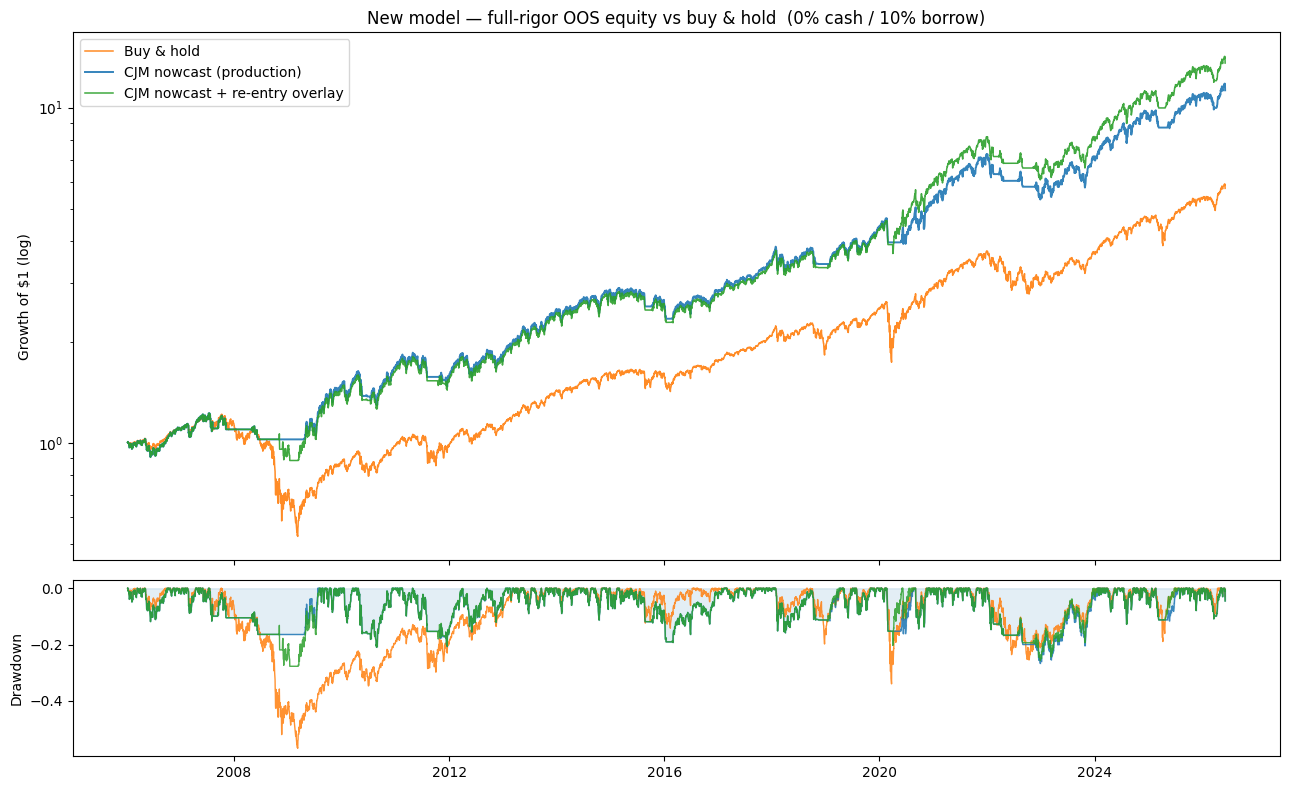

CJM nowcast (production)            ann +12.6%  Sharpe 0.69  maxDD -27%   (vs B&H: ann +3.7%, Sharpe +0.23, DD +30%)
CJM nowcast + re-entry overlay      ann +13.7%  Sharpe 0.71  maxDD -28%   (vs B&H: ann +4.7%, Sharpe +0.25, DD +29%)


In [37]:
# --- Equity curves (growth of $1, log) + drawdown paths for the three lines. ---
eq = pd.DataFrame({
    "Buy & hold":                      bt_prod["equity"]["buy_hold"],
    "CJM nowcast (production)":        bt_prod["equity"]["strategy"],
    "CJM nowcast + re-entry overlay": bt_ov["equity"]["strategy"],
}).dropna()
dd = eq / eq.cummax() - 1.0

colors = {"Buy & hold": "tab:orange",
          "CJM nowcast (production)": "tab:blue",
          "CJM nowcast + re-entry overlay": "tab:green"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
for col in eq.columns:
    ax1.plot(eq.index, eq[col], label=col, lw=1.4 if "production" in col else 1.1,
             color=colors[col], alpha=0.9)
ax1.set_yscale("log"); ax1.set_ylabel("Growth of $1 (log)")
ax1.set_title("New model — full-rigor OOS equity vs buy & hold  (0% cash / 10% borrow)")
ax1.legend(loc="upper left")

for col in dd.columns:
    ax2.plot(dd.index, dd[col], color=colors[col], lw=1.0, alpha=0.85)
ax2.fill_between(dd.index, dd["CJM nowcast (production)"], 0, color="tab:blue", alpha=0.12)
ax2.set_ylabel("Drawdown"); ax2.set_xlabel("")
plt.tight_layout(); plt.show()

# A compact "vs buy & hold" read for the two strategy lines.
bh = new_metrics.loc["Buy & hold"]
for name in ["CJM nowcast (production)", "CJM nowcast + re-entry overlay"]:
    m = new_metrics.loc[name]
    print(f"{name:34s}  ann {m['annual_return']:+.1%}  Sharpe {m['sharpe']:.2f}  "
          f"maxDD {m['max_drawdown']:.0%}   "
          f"(vs B&H: ann {m['annual_return']-bh['annual_return']:+.1%}, "
          f"Sharpe {m['sharpe']-bh['sharpe']:+.2f}, "
          f"DD {m['max_drawdown']-bh['max_drawdown']:+.0%})")


### How the model reads the tape — bear regimes + re-entry cues

The visual "x-ray" of the model on the full out-of-sample history. On the S&P 500
price (log scale):

- **Red spans** = days the model **detects a bear regime** (`bear_prob ≥ 0.5`, the
  same call threshold used in the diagnostics) — where the overlay de-risks / you'd
  be short or in cash.
- **Green ▲ + shaded gap** = the **re-entry cue** for each bear episode: the first
  time the rebound gate confirms after the bear regime ends (S&P ≥ 10% above its
  trailing 42-day low **and** VIX below its 21-day average). The green gap is the
  **re-entry delay** (how long after the regime cleared before the cue fired). To
  keep it readable we show *one cue per bear episode* — the dozens of shallow-dip
  fires in calm bull markets are omitted.

The lower panel shows the raw `bear_prob` (blue fill) vs the overlay-capped
`bear_prob_overlay` (green); where they diverge is exactly where the re-entry gate
pulls the reading down to the `cap` (0.20).


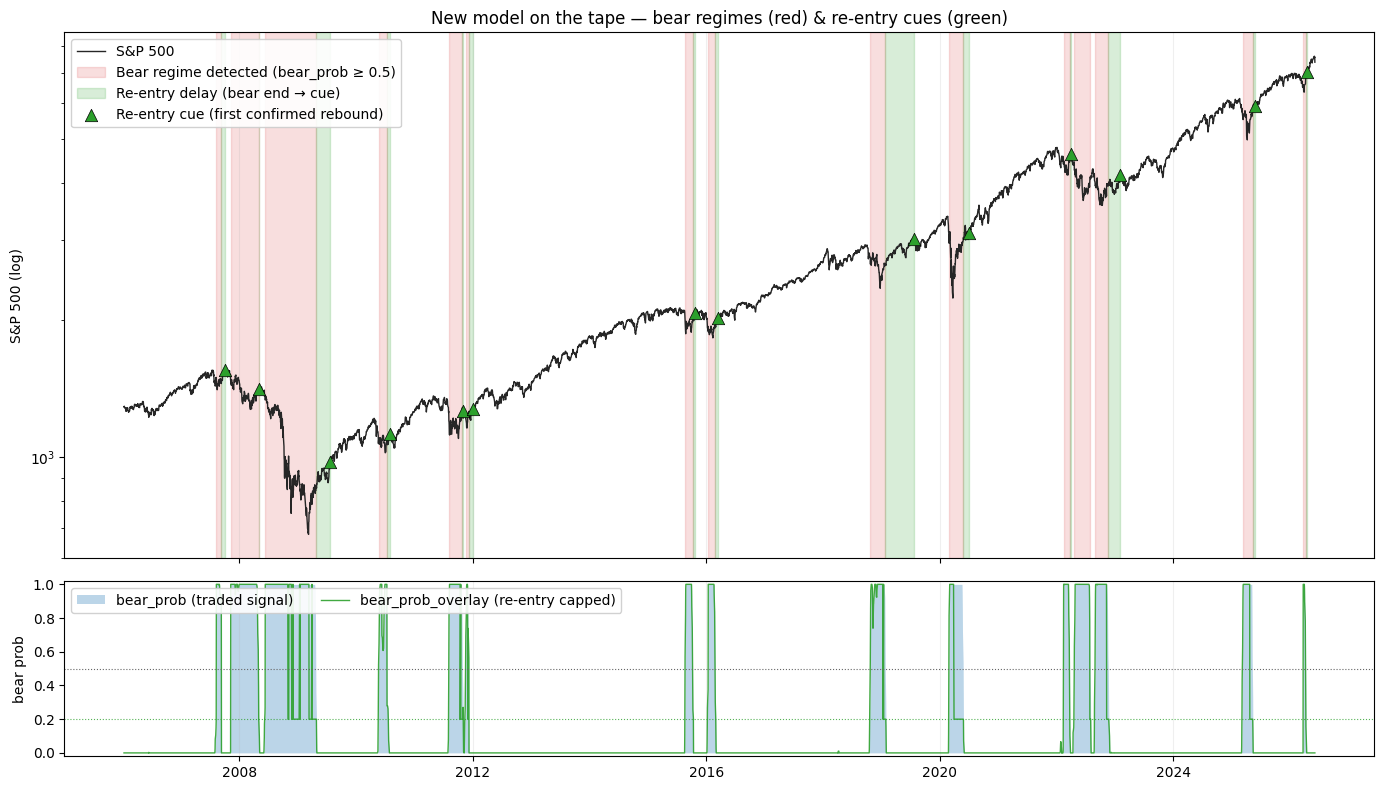

Bear-regime episodes detected: 15   days in bear regime: 16.7%
Re-entry cues shown: 14 (one per bear episode that rebounds)


In [39]:
# --- Visual: bear-regime detection + re-entry triggers over the S&P 500 price. ---
def _spans(mask: pd.Series):
    """Convert a boolean time series into a list of (start, end) contiguous spans."""
    mask = mask.fillna(False).astype(bool)
    if not mask.any():
        return []
    idx = mask.index
    change = mask.ne(mask.shift())          # True where the value flips
    starts = idx[change & mask]             # rising edges (False->True)
    spans = []
    for s in starts:
        rest = mask.loc[s:]
        end = rest[~rest].index[0] if (~rest).any() else rest.index[-1]
        spans.append((s, end))
    return spans

THRESH = 0.5
bp     = ov["bear_prob"]                    # raw production nowcast
bp_ov  = ov["bear_prob_overlay"]            # capped on confirmed rebounds
flag   = ov["reentry_flag"].astype(bool)
price  = feat["market"].reindex(bp.index).ffill()

bear_mask  = bp >= THRESH
bear_spans = _spans(bear_mask)
flag_edges = [s for (s, _e) in _spans(flag)]   # every day the gate first re-arms

# Keep only the ONE actionable re-entry cue per bear episode: the first time the
# gate fires at/after each bear regime ends (before the next bear regime starts).
# This strips the dozens of shallow-dip fires in calm bull markets that buried
# the signal, leaving the "cover shorts / re-enter" cues that matter.
reentry_cues = []   # (bear_end, cue_date) pairs
for j, (s, e) in enumerate(bear_spans):
    next_bear = bear_spans[j + 1][0] if j + 1 < len(bear_spans) else price.index[-1]
    later = [d for d in flag_edges if e <= d < next_bear]
    if later:
        reentry_cues.append((e, later[0]))
cue_dates = [c for (_e, c) in reentry_cues]

fig, (axp, axb) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# --- Top: price with bear-regime shading + the re-entry cue per episode ---
axp.plot(price.index, price, color="0.15", lw=1.0, label="S&P 500")
for i, (s, e) in enumerate(bear_spans):
    axp.axvspan(s, e, color="tab:red", alpha=0.15,
                label="Bear regime detected (bear_prob ≥ 0.5)" if i == 0 else None)
# Shade the gap between each bear-regime end and its re-entry cue = the re-entry lag.
for i, (e, c) in enumerate(reentry_cues):
    axp.axvspan(e, c, color="tab:green", alpha=0.18,
                label="Re-entry delay (bear end → cue)" if i == 0 else None)
axp.scatter(cue_dates, price.reindex(cue_dates), marker="^", s=80,
            color="tab:green", edgecolor="black", lw=0.5, zorder=5,
            label="Re-entry cue (first confirmed rebound)")
axp.set_yscale("log"); axp.set_ylabel("S&P 500 (log)")
axp.set_title("New model on the tape — bear regimes (red) & re-entry cues (green)")
axp.grid(True, which="major", axis="x", alpha=0.2)
axp.legend(loc="upper left", framealpha=0.9)

# --- Bottom: bear_prob (filled) vs the overlay-capped reading ---
axb.fill_between(bp.index, 0, bp, color="tab:blue", alpha=0.30, lw=0,
                 label="bear_prob (traded signal)")
axb.plot(bp_ov.index, bp_ov, color="tab:green", lw=1.0, alpha=0.9,
         label="bear_prob_overlay (re-entry capped)")
axb.axhline(THRESH, ls=":", color="0.4", lw=0.8)
axb.axhline(config.REENTRY_CAP, ls=":", color="tab:green", lw=0.8, alpha=0.8)
axb.set_ylim(-0.02, 1.02); axb.set_ylabel("bear prob"); axb.set_xlabel("")
axb.grid(True, axis="x", alpha=0.2)
axb.legend(loc="upper left", ncol=2, framealpha=0.9)
plt.tight_layout(); plt.show()

print(f"Bear-regime episodes detected: {len(bear_spans)}   "
      f"days in bear regime: {bear_mask.mean():.1%}")
print(f"Re-entry cues shown: {len(cue_dates)} (one per bear episode that rebounds)")


### Read — how the new model behaves (full-rigor OOS, 2006 → 2026)

**Backtest vs buy & hold** (0% cash / 10% borrow):

| Line | Ann return | Sharpe | Max DD | Growth of $1 |
| --- | --- | --- | --- | --- |
| Buy & hold | 9.0% | 0.46 | **−57%** | 5.7× |
| **CJM nowcast (production)** | **12.6%** | **0.69** | **−27%** | 11.3× |
| CJM nowcast + re-entry overlay | 13.7% | 0.71 | −28% | 13.6× |

- **The production signal is doing its job:** ~+3.7%/yr over B&H, Sharpe 0.46 →
  0.69, and the headline win is **halving the worst drawdown (−57% → −27%)** — it
  steps aside in 2008 and 2020 (visible as the flat shelves in the equity curve).
  This is a *risk/volatility* detector, not a return-timer, exactly as the
  signal-quality study found.
- **The re-entry overlay adds ~+1%/yr and ~13× total** for ~1 extra DD point — it
  rejoins the rebounds faster (the green spans/▲ cluster right off the 2009, 2020
  and 2022 lows) instead of sitting out the recovery. In production it's still
  **display-only**; this is the "what if we traded it" view.

**On the tape:** the model flagged **15 bear-regime episodes** (16.7% of days),
correctly lighting up red through GFC, late-2018, COVID and the 2022 bear, and the
**re-entry trigger fires near the bottoms** — the intended "cover shorts / re-enter"
cue. Caveat (per §14): re-entry triggers also fire on shallow dips, and short-
**entry** timing on grinding declines is still the open gap (not addressed here).
